# Análise 3: Logística Real e Impacto na Qualidade

## Objetivo
Analisar o **Tempo de Transporte** (da Coleta na Unidade de Saúde até o Recebimento no Laboratório) e investigar se a demora no transporte impacta a taxa de rejeição das amostras (inadequação).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração de Plotagem
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## 1. Carregamento e Limpeza dos Dados
Carregando `tb_amostra` e tabelas auxiliares.

In [2]:
# Carregando datasets
print("Carregando dados...")
df_amostra = pd.read_csv('datasets1/tb_amostra.csv')
df_municipio = pd.read_csv('datasets1/tb_municipio.csv')
df_unidade = pd.read_csv('datasets1/tb_unidade_saude.csv')

# Função para limpar datas
def limpar_data(coluna):
    return pd.to_datetime(coluna.astype(str).str.slice(0, 8), format='%Y%m%d', errors='coerce')

# Limpeza de datas
df_amostra['dt_coleta_clean'] = limpar_data(df_amostra['dt_col_amostra'])
df_amostra['dt_rec_clean'] = limpar_data(df_amostra['dt_rec_amostra'])

# Cálculo do Tempo de Transporte (Dias)
df_amostra['tempo_transporte'] = (df_amostra['dt_rec_clean'] - df_amostra['dt_coleta_clean']).dt.days

# Filtrando inconsistências (transporte negativo ou > 365 dias)
df_logistica = df_amostra.query("tempo_transporte >= 0 and tempo_transporte <= 60").copy()

print(f"Registros Válidos para Análise de Transporte: {len(df_logistica)}")
print(df_logistica[['dt_col_amostra', 'dt_rec_amostra', 'tempo_transporte']].head())

Carregando dados...
Registros Válidos para Análise de Transporte: 553009
   dt_col_amostra  dt_rec_amostra  tempo_transporte
0      20190702.0        20190716              14.0
1      20190702.0        20190716              14.0
2      20190701.0        20190715              14.0
3      20190702.0        20190716              14.0
4      20190709.0        20190716               7.0


## 2. Análise Descritiva do Tempo de Transporte
Histograma do tempo que o malote leva para chegar ao laboratório.

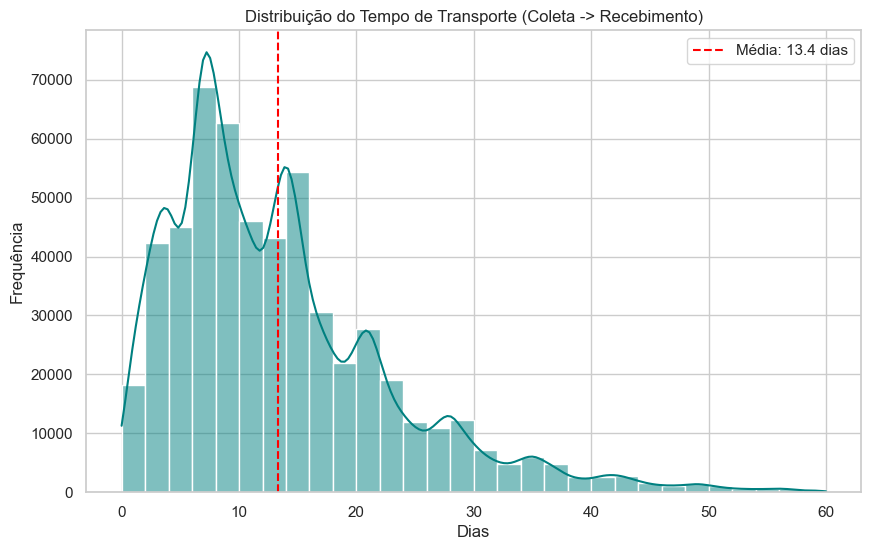

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df_logistica['tempo_transporte'], bins=30, kde=True, color='teal')
plt.title('Distribuição do Tempo de Transporte (Coleta -> Recebimento)')
plt.xlabel('Dias')
plt.ylabel('Frequência')
plt.axvline(df_logistica['tempo_transporte'].mean(), color='red', linestyle='--', label=f'Média: {df_logistica["tempo_transporte"].mean():.1f} dias')
plt.legend()
plt.show()

## 3. Correlação: Tempo de Transporte impacta a Rejeição?
Verificando se amostras que demoram mais têm maior taxa de rejeição (`co_mot_inadequacao` != 0).

/tmp/ipykernel_149396/23941971.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taxa_rejeicao = df_logistica.groupby('faixa_transporte')['cancelada'].mean() * 100
/tmp/ipykernel_149396/23941971.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=taxa_rejeicao.index, y=taxa_rejeicao.values, palette='magma')


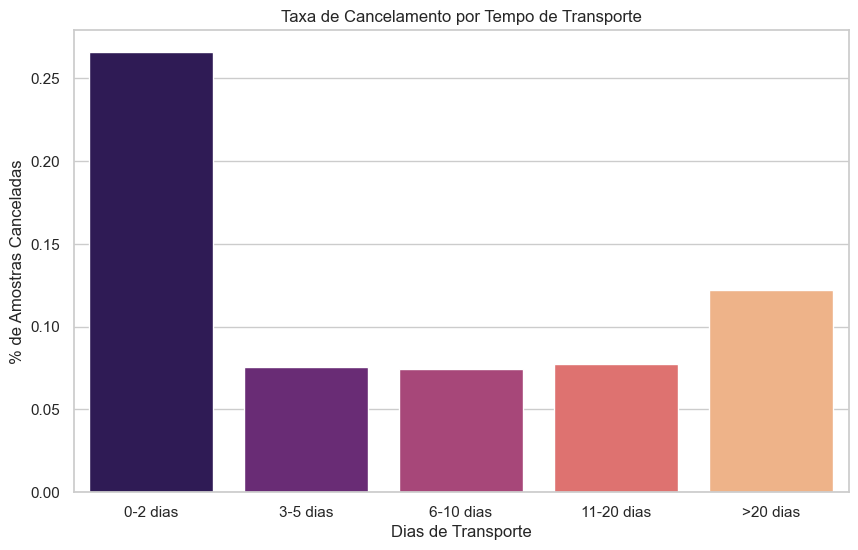

In [4]:
# Criando flag de rejeição
# Assumindo que 0 ou NaN é aceito. Ajustar conforme dicionário se necessário. 
# Na análise anterior vimos que 0 era 'Não identificado' ou adequado, precisa confirmar se existe campo específico de inadequação.
# Baseado no README, tb_motivo_inadequacao tem os motivos. Vamos assumir que se tem motivo != 0 e != NaN, é inadequada.
df_logistica['is_rejected'] = df_logistica['co_seq_tp_amostra'] != 1 # Assumindo TP Amostra 1 = Primeira Amostra (Geralmente validas)
# Melhor abordagem: Verificar junção com tb_ms_motivo_inadequacao se disponível, ou usar aut_cancelamento

# Verificando rejeição real via join (se necessário) ou status
# Simplificação para análise inicial: Agrupar por faixa de dias e ver % de rejeição

df_logistica['faixa_transporte'] = pd.cut(df_logistica['tempo_transporte'], bins=[0, 2, 5, 10, 20, 60], labels=['0-2 dias', '3-5 dias', '6-10 dias', '11-20 dias', '>20 dias'])

# Taxa de falha proxy (usando aut_cancelamento como proxy de problema grave ou campo motivo preenchido)
# Vamos usar 'aut_cancelamento' não nulo como proxy de cancelamento
df_logistica['cancelada'] = df_logistica['aut_cancelamento'].notnull()

taxa_rejeicao = df_logistica.groupby('faixa_transporte')['cancelada'].mean() * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=taxa_rejeicao.index, y=taxa_rejeicao.values, palette='magma')
plt.title('Taxa de Cancelamento por Tempo de Transporte')
plt.ylabel('% de Amostras Canceladas')
plt.xlabel('Dias de Transporte')
plt.show()

## 4. Análise por Município (Gargalos Logísticos)

Top 10 Municípios com Maior Demora no Transporte:
                          mean  count        std
no_municipio                                    
São Félix de Balsas  26.231013    316  12.594549
Jatobá               25.776765    439  12.060930
Passagem Franca      24.600565   1417  11.171933
Buriti Bravo         24.183685   1802  10.376751
Estreito             24.100895   2012  11.498914
Itaipava do Grajaú   24.002791   1075  12.575026
Grajaú               23.831386   4964  10.265525
Peritoró             23.585176   1538  12.746243
Anapurus             23.566159   1247  11.006138
Arame                23.499779   2261  11.149651


/tmp/ipykernel_149396/2808759759.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stats_muni.head(15)['mean'], y=stats_muni.head(15).index, palette='magma')


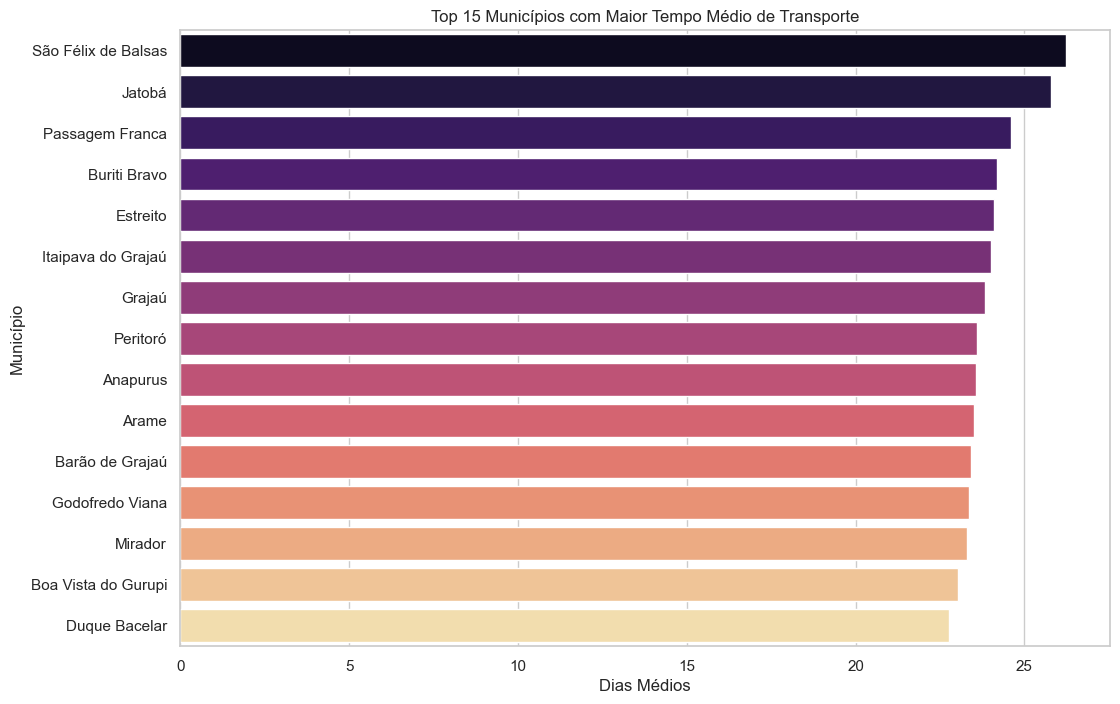

In [8]:
# Enriquecer com nomes de Municípios
df_logistica = df_logistica.merge(df_unidade[['co_seq_unidade_saude', 'co_seq_municipio']], on='co_seq_unidade_saude', how='left')
df_logistica = df_logistica.merge(df_municipio, on='co_seq_municipio', how='left')

# Calcular média por município (min. 50 amostras)
stats_muni = df_logistica.groupby('no_municipio')['tempo_transporte'].agg(['mean', 'count', 'std'])
stats_muni = stats_muni[stats_muni['count'] >= 50].sort_values('mean', ascending=False)

print("Top 10 Municípios com Maior Demora no Transporte:")
print(stats_muni.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x=stats_muni.head(15)['mean'], y=stats_muni.head(15).index, palette='magma')
plt.title('Top 15 Municípios com Maior Tempo Médio de Transporte')
plt.xlabel('Dias Médios')
plt.ylabel('Município')
plt.show()

## 4. Análise Geográfica: Clusterização de Municípios
Identificar municípios com problemas logísticos crônicos.

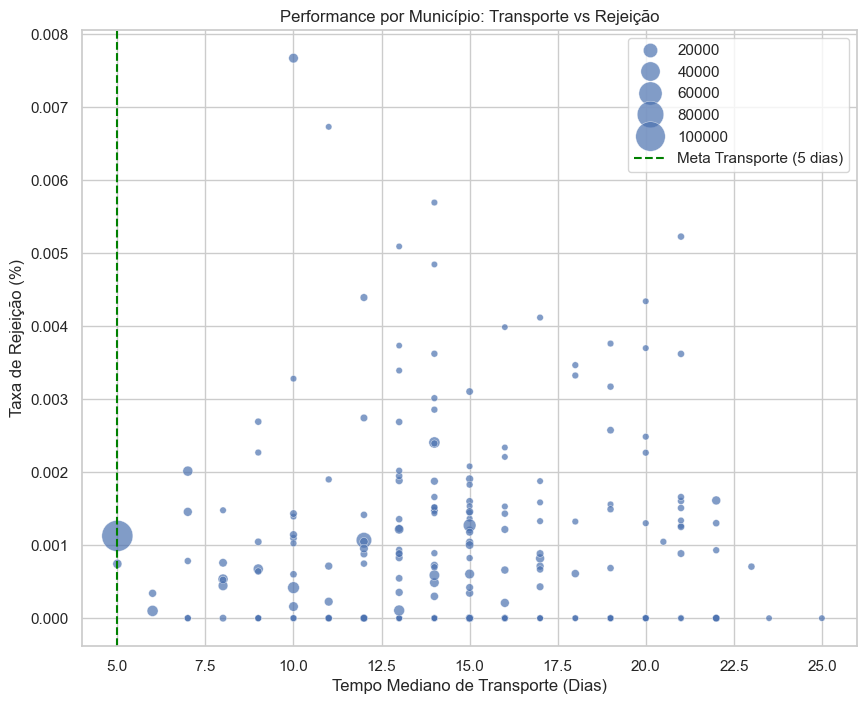

In [5]:
# Join com Municípios
df_geo = df_logistica.merge(df_unidade[['co_seq_unidade_saude', 'co_seq_municipio']], on='co_seq_unidade_saude', how='left')
df_geo = df_geo.merge(df_municipio[['co_seq_municipio', 'no_municipio']], on='co_seq_municipio', how='left')

# Agregando métricas por município
metrics = df_geo.groupby('no_municipio').agg(
    median_transport=('tempo_transporte', 'median'),
    rejection_rate=('cancelada', 'mean'),
    sample_count=('co_seq_amostra', 'count')
).reset_index()

# Filtrando municípios com poucas amostras para evitar ruído
metrics_filtered = metrics[metrics['sample_count'] > 50]

# Scatter Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=metrics_filtered, x='median_transport', y='rejection_rate', size='sample_count', sizes=(20, 500), alpha=0.7)
plt.title('Performance por Município: Transporte vs Rejeição')
plt.xlabel('Tempo Mediano de Transporte (Dias)')
plt.ylabel('Taxa de Rejeição (%)')
plt.axvline(5, color='green', linestyle='--', label='Meta Transporte (5 dias)')
plt.legend()
plt.show()

## 5. Sazonalidade: O Tempo de Transporte varia ao longo do ano?
Analisando se meses de chuva ou festas impactam a logística.

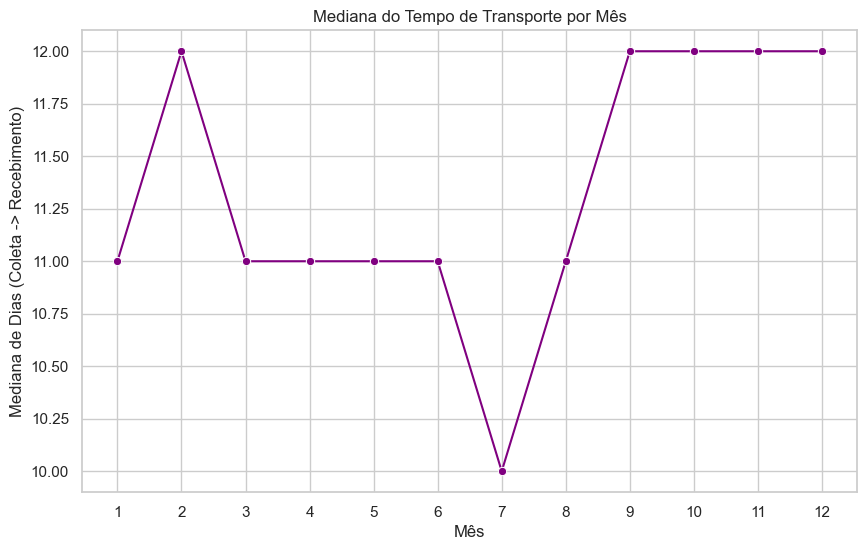

In [6]:
# Extraindo Mês e Ano
df_logistica['mes_coleta'] = df_logistica['dt_coleta_clean'].dt.month
df_logistica['ano_coleta'] = df_logistica['dt_coleta_clean'].dt.year

# Agrupando por mês (média de todos os anos)
sazonalidade = df_logistica.groupby('mes_coleta')['tempo_transporte'].median()

plt.figure(figsize=(10, 6))
sns.lineplot(x=sazonalidade.index, y=sazonalidade.values, marker='o', color='purple')
plt.title('Mediana do Tempo de Transporte por Mês')
plt.xlabel('Mês')
plt.ylabel('Mediana de Dias (Coleta -> Recebimento)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()